# 📊 Placement Prediction Using Machine Learning

---

## 👩‍💻 Student Details

- **Name:** Saniya Shaikh  
- **Project Title:** Placement Prediction Using Machine Learning  
- **Domain:** Data Science / Machine Learning  
- **Tools Used:** Python, Pandas, NumPy, Seaborn, Scikit-learn  

---

## 🔹 Step 1: Import Libraries

In this step, we import essential libraries such as **Pandas**, **NumPy**, **Seaborn**, and **Matplotlib**.  
These libraries are used for **data manipulation**, **numerical operations**, and **data visualization**.  

**Pandas** helps in handling and analyzing structured data,  
**NumPy** is used for performing numerical computations,  
**Seaborn** and **Matplotlib** are used for creating visualizations such as graphs and plots.  

These libraries form the foundation for performing **data analysis** and building the **machine learning model efficiently**.

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 🔹 Step 2: Load Dataset

The dataset is loaded using the **pandas library**.  
This dataset contains **student academic details** and **placement status**.  
The **head() function** is used to display the first few rows of the dataset to understand its structure.

In [38]:
df = pd.read_csv('/kaggle/input/datasets/barkhaverma/placement-data-full-class/Placement_data_full_class.csv')
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


## 🔹 Step 3: Data Understanding

In this step, we explore the dataset using **info()**, **describe()**, and **isnull().sum()**.  
These functions provide information about **data types**, **statistical summary**, and **missing values**.  
This step is important to understand the dataset before applying machine learning.

In [39]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

## 🔹 Step 4: Handle Missing Values

The dataset may contain **missing values**, which can affect model performance.  
In this step, missing values are replaced using the **mean of the column**.  
This ensures that the dataset becomes clean and suitable for further processing.

In [40]:
df['salary'] = df['salary'].fillna(df['salary'].mean())

## 🔹 Step 5: Data Visualization (Count Plot)

A **count plot** is used to visualize the distribution of **placement status**.  
This helps in understanding how many students are **placed** and **not placed**.  
Visualization makes it easier to identify patterns in the dataset.

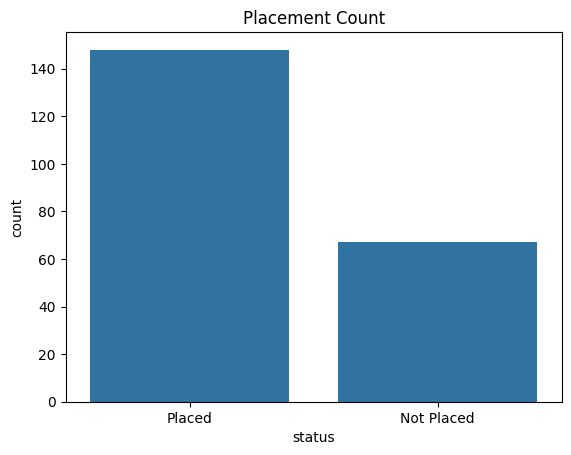

In [41]:
sns.countplot(x='status', data=df)
plt.title("Placement Count")
plt.show()

## 🔹 Step 6: Box Plot Analysis

A **box plot** is used to analyze the relationship between **SSC percentage** and **placement status**.  
It helps in understanding whether **academic performance** affects placement opportunities.

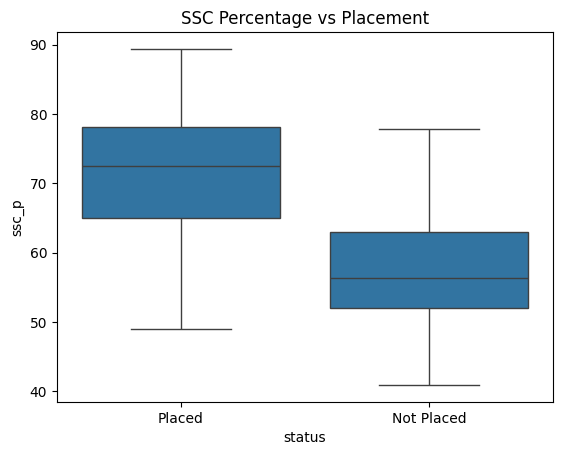

In [42]:
sns.boxplot(x='status', y='ssc_p', data=df)
plt.title("SSC Percentage vs Placement")
plt.show()

## 🔹 Step 7: Work Experience Analysis

This step analyzes the impact of **work experience** on placement.  
A **count plot** is used to compare students with and without work experience.  
It helps in understanding whether experience improves placement chances.

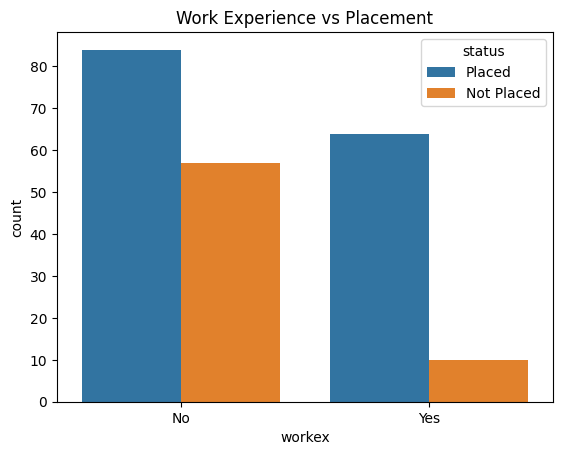

In [43]:
sns.countplot(x='workex', hue='status', data=df)
plt.title("Work Experience vs Placement")
plt.show()

## 🔹 Step 8: Convert Categorical Data

Machine learning models require **numerical input**.  
Therefore, categorical variables such as **gender**, **status**, and **work experience** are converted into numerical values using **mapping**.

In [44]:
df['gender'] = df['gender'].map({'M':1,'F':0})
df['status'] = df['status'].map({'Placed':1,'Not Placed':0})
df['workex'] = df['workex'].map({'Yes':1,'No':0})

## 🔹 Step 9: Correlation Heatmap

A **heatmap** is used to visualize the **correlation between features**.  
It helps in identifying which variables are strongly related to each other.  
The **coolwarm color map** improves visualization clarity.

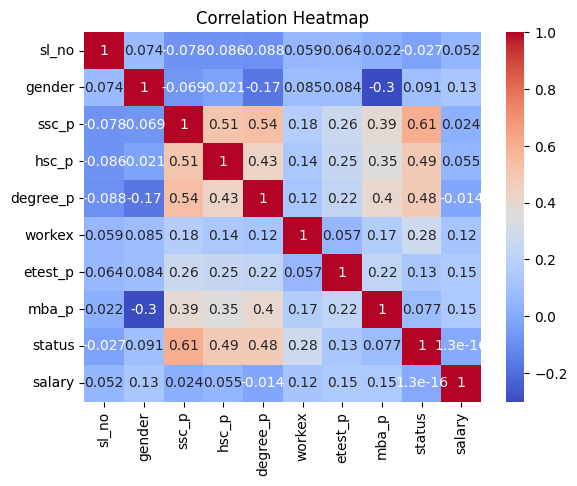

In [45]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## 🔹 Step 10: Feature & Target Selection

In this step, input features (**X**) and the target variable (**y**) are defined.  
Features include **academic scores** and **work experience**, while the target represents **placement status**.

In [46]:
X = df[['ssc_p','hsc_p','degree_p','etest_p','mba_p','workex']]
y = df['status']

## 🔹 Step 11: Handle Missing Values in Features

To avoid errors during model training, missing values in input features are handled.  
The **mean value** is used to replace missing values, ensuring data consistency.

In [47]:
X = X.fillna(X.mean())

## 🔹 Step 12: Train-Test Split

The dataset is divided into **training data** and **testing data**.  
The model is trained on training data and evaluated on testing data to check performance.

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## 🔹 Step 13: Feature Scaling

Feature scaling is applied using **StandardScaler**.  
This normalizes the data and improves the **accuracy and performance** of the model.

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 🔹 Step 14: Model Building (Logistic Regression)

The **Logistic Regression algorithm** is used to train the model.  
This algorithm is suitable for **classification problems**, such as predicting placement.

In [50]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## 🔹 Step 15: Prediction

The trained model is used to make predictions on the test dataset.  
The output shows whether a student will be **placed or not placed**.

In [51]:
y_pred = model.predict(X_test)
print(y_pred)

[0 1 1 1 0 1 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1 0 0 1 0 1 0 0
 1 0 1 1 1 1]


## 🔹 Step 16: Model Evaluation

The model is evaluated using **confusion matrix**, **classification report**, and **accuracy score**.  
These metrics help in understanding how well the model is performing.

In [52]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

[[14  4]
 [ 0 25]]
              precision    recall  f1-score   support

           0       1.00      0.78      0.88        18
           1       0.86      1.00      0.93        25

    accuracy                           0.91        43
   macro avg       0.93      0.89      0.90        43
weighted avg       0.92      0.91      0.90        43

Accuracy: 0.9069767441860465


## 🔹 Step 17: Model Comparison (KNN)

The **K-Nearest Neighbors (KNN)** algorithm is used to compare performance with Logistic Regression.  
This helps in selecting the best model.

In [53]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.813953488372093


## 🔹 Step 18: Sample Prediction

In this step, a **sample input** is provided to the trained machine learning model to test its real-world prediction capability.  
This sample represents a student's academic details such as **SSC percentage**, **HSC percentage**, **degree percentage**, **employability test score**, **MBA percentage**, and **work experience**.

Before making the prediction, the input data is transformed using the same **feature scaling technique (StandardScaler)** that was applied during model training.  
This ensures that the input data is in the same format as the training data, which helps in maintaining prediction accuracy.

The trained **Logistic Regression model** is then used to predict whether the student will be **placed or not placed**.  
This step demonstrates how the model can be used in **real-life scenarios** to make predictions based on new input data.

Overall, this step highlights the practical application of the machine learning model and shows how it can assist in decision-making processes.

In [54]:
sample = [[75, 80, 70, 85, 78, 1]]
sample = scaler.transform(sample)

prediction = model.predict(sample)
print("Prediction:", prediction)

Prediction: [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
